Display the number of vehices by zip code on map. 
Required libraries: geopandas matplotlib folium plotly

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Load data
folder = "/Users/fanyang/Documents/Family/kids/ScienceFair2024/calculation/geology/"
file_name = "Vehicle_Population_Last_updated_04-30-2024_ada_2023_EV_PHEV.csv"
ev_data = gpd.read_file(folder + file_name)



Matplotlib is building the font cache; this may take a moment.


In [3]:
# Senity check
print(ev_data.columns)
print(ev_data['Number of Vehicles'].dtype)

# Ensure the column is numeric
ev_data['Number of Vehicles'] = pd.to_numeric(ev_data['Number of Vehicles'], errors='coerce')
ev_data['ZIP'] = pd.to_numeric(ev_data['ZIP'], errors='coerce')

# Drop rows with NaN values (if needed)
ev_data = ev_data.dropna(subset=['Number of Vehicles'])

# Verify the data
print(ev_data['Number of Vehicles'].dtype)
print(ev_data['Number of Vehicles'].head())


Index(['Data Year', 'Dashboard Fuel Type Group', 'Fuel Type', 'ZIP',
       'Number of Vehicles'],
      dtype='object')
object
int64
0       1
1     167
2     167
3     197
4    1292
Name: Number of Vehicles, dtype: int64


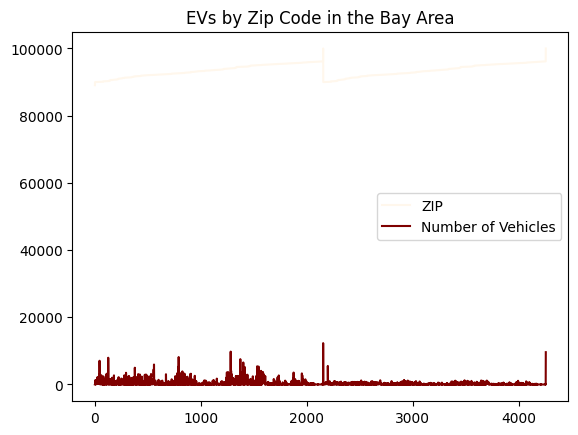

In [4]:
# Plot choropleth map
ev_data.plot(column='Number of Vehicles', legend=True, cmap='OrRd')
plt.title('EVs by Zip Code in the Bay Area')
plt.show()

In [5]:
# plot the outline of all zip codes in the Bay Area


# Interactive Map with folium
import folium
from folium.plugins import HeatMap

# Create a base map
m = folium.Map(location=[37.7749, -122.4194], zoom_start=10)
folder_result = "/Users/fanyang/Documents/Family/kids/ScienceFair2024/calculation/results/"

# Add choropleth layer
folium.Choropleth(
    geo_data=folder+'Bay Area ZIP Codes_20250101.geojson',
    data=ev_data,
    columns=['ZIP', 'Number of Vehicles'],
    key_on='feature.properties.zip',
    fill_color='OrRd',
    legend_name='Number of EVs'
).add_to(m)

m.save(folder_result+'ev_map.html')


In [7]:
# each polygon will have a different color, where the particular fill_color 
# is determined by the value of "Number of Vehicles" of the corresponding zip value

# Define a function to map 'Number of Vehicles' to a color
def get_color(value, min_value, max_value, color_scale='OrRd'):
    """
    Maps a value to a color in the specified color scale.
    """
    import matplotlib.colors as colors
    from matplotlib import colormaps  # Import colormaps directly

    # Normalize the value between 0 and 1
    norm = colors.Normalize(vmin=min_value, vmax=max_value)
    # Get the color scale
    cmap = colormaps.get_cmap(color_scale)  # Use colormaps.get_cmap
    # Map the normalized value to a color
    rgba = cmap(norm(value))
    # Convert RGBA to hex color
    return colors.rgb2hex(rgba)

# Get the min and max values of 'Number of Vehicles'
min_vehicles = ev_data['Number of Vehicles'].min()
max_vehicles = ev_data['Number of Vehicles'].max()

# Add GeoJson layer with custom styling
folium.GeoJson(
    folder + 'Bay Area ZIP Codes_20250101.geojson',  # Path to GeoJSON file
    style_function=lambda feature: {
        'fillColor': get_color(
            ev_data.loc[ev_data['ZIP'] == int(feature['properties']['zip']), 'Number of Vehicles'].values[0]
            if not ev_data.loc[ev_data['ZIP'] == int(feature['properties']['zip']), 'Number of Vehicles'].empty
            else min_vehicles,  # Default to min_value if no match is found
            min_vehicles,
            max_vehicles,
            color_scale='OrRd'
        ),
        'color': 'black',  # Border color
        'weight': 1,  # Border width
        'fillOpacity': 0.7  # Fill opacity
    },
    tooltip=folium.features.GeoJsonTooltip(
        fields=['zip'],  # Show ZIP code in tooltip
        aliases=['ZIP Code:'],  # Tooltip label
        localize=True
    )
).add_to(m)

# Save the updated map
m.save(folder_result + 'ev_choropleth_map.html')

In [11]:
'''# Define a function to map 'Number of Vehicles' to a color
def get_color(value, min_value, max_value, color_scale='OrRd'):
    """
    Maps a value to a color in the specified color scale.
    """
    import matplotlib.colors as colors
    from matplotlib import colormaps  # Import colormaps directly

    # Normalize the value between 0 and 1
    norm = colors.Normalize(vmin=min_value, vmax=max_value)
    # Get the color scale
    cmap = colormaps.get_cmap(color_scale)  # Use colormaps.get_cmap
    # Map the normalized value to a color
    rgba = cmap(norm(value))
    # Convert RGBA to hex color
    return colors.rgb2hex(rgba)

# Get the min and max values of 'Number of Vehicles'
min_vehicles = ev_data['Number of Vehicles'].min()
max_vehicles = ev_data['Number of Vehicles'].max()

# Add GeoJson layer with custom styling and enhanced tooltip
folium.GeoJson(
    folder + 'Bay Area ZIP Codes_20250101.geojson',  # Path to GeoJSON file
    style_function=lambda feature: {
        'fillColor': get_color(
            ev_data.loc[ev_data['ZIP'] == int(feature['properties']['zip']), 'Number of Vehicles'].values[0]
            if not ev_data.loc[ev_data['ZIP'] == int(feature['properties']['zip']), 'Number of Vehicles'].empty
            else min_vehicles,  # Default to min_value if no match is found
            min_vehicles,
            max_vehicles,
            color_scale='OrRd'
        ),
        'color': 'black',  # Border color
        'weight': 1,  # Border width
        'fillOpacity': 0.7  # Fill opacity
    },
    tooltip=folium.features.GeoJsonTooltip(
        fields=['zip'],  # Only include fields from the GeoJSON
        aliases=['ZIP Code:'],  # Label for the ZIP code
        localize=True,
        style=(
            "background-color: white; color: black; font-family: Arial; font-size: 12px; padding: 5px;"
        ),
        labels=True,  # Enable labels
        to_string=lambda feature: (
            f"ZIP Code: {feature['properties']['zip']}<br>"
            f"Vehicle Number: {ev_data.loc[ev_data['ZIP'] == int(feature['properties']['zip']), 'Number of Vehicles'].values[0] if not ev_data.loc[ev_data['ZIP'] == int(feature['properties']['zip']), 'Number of Vehicles'].empty else 'N/A'}"
        )  # Custom tooltip content
    )
).add_to(m)

# Save the updated map
m.save(folder_result + 'ev_custom_choropleth_map.html')

AssertionError: The field Number of Vehicles is not available in the data. Choose from: ('area', 'zip', 'state', 'po_name', 'length').